# Kapitel 3 – Hitzewarnung

In diesem Abschnitt möchten wir tägliche Maximaltemperaturen aus einer Liste verarbeiten und schrittweise zu einem kleinen Entscheidungsmodell für Hitzetage ausbauen. Ausgangspunkt ist eine feste Liste von Temperaturwerten, die wir im Programm als Python‑Liste speichern:

In [1]:
temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

In dieser Liste steht an Stelle 0 die Temperatur des ersten Tages, an Stelle 1 jene des zweiten Tages, und so weiter. Man kann sich die Liste also als kleine Zeitreihe vorstellen: Tag 0, Tag 1, Tag 2, … mit jeweils einer Maximaltemperatur.

Um mit dieser Liste zu arbeiten, verwenden wir eine **For‑Schleife**. Eine For‑Schleife führt einen bestimmten Befehl mehrmals hintereinander aus. Das kenn wir schon: Was aber neu ist: Die Zahl `it` (den so genannten Iterator) darf man auch im Code verwenden. Er zählt mit, wie oft die Schleife durchlaufen worden ist und ändert somit jedes Mal seinen Wert.

Und auch über **Listen** können wir etwas neues lernen: Man kann sie nicht nur als ganzes verwenden (um sie z.B. zu plotten) sondern kann auch einzele Elemente davon auswählen. Das macht man mit `name_der_liste[element]` wobei `element` eine Ganzzahl ist. 0 liefert das erste Element, 1 liefert das zweite und so weiter.



Wenn wir unser neues Wissen über den Iterator und Listen kombinieren, können wir für jeden Eintrag in der Liste die Temperatur ausgeben. Dazu verwenden wir `range(len(temperatures))`. Der Befehl `len(temperatures)` berechnet die Länge der Liste, also wie viele Werte darin stehen.  Innerhalb der Schleife greifen wir mit `temperatures[it]` auf die Temperatur an der Position `it` zu und geben sie aus:

In [2]:
temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

for it in range(len(temperatures)):
    print(temperatures[it])

35
31
33
32
30
29
27
30
31
33
31
26
28
30


Der Programmablauf ist hier einfach: Die Schleife startet mit it = 0, gibt temperatures[0] aus, dann it = 1 mit temperatures[1], und so weiter, bis alle Einträge verarbeitet wurden. So kann man die Daten kontrollieren und sehen, welche Werte überhaupt vorliegen.

Im nächsten Schritt möchten wir aus diesen Zahlen eine erste Entscheidung ableiten: Soll es an einem Tag eine Hitzewarnung geben oder nicht? Dazu benötigen wir eine Struktur, mit der sich Bedingungen formulieren lassen. In Python übernimmt diese Aufgabe die **if‑Abfrage**. Eine if‑Abfrage hat immer eine Bedingung, die entweder wahr oder falsch sein kann, und einen oder mehrere Befehle, die nur dann ausgeführt werden sollen, wenn die Bedingung wahr ist. Eine typische Struktur lautet:

```
if BEDINGUNG:
    BEFEHL
```

Man kann diese Struktur wie „Wenn … dann …“ lesen. Die Bedingung ist in unserem Fall ein Vergleich: wir möchten wissen, ob die Temperatur über einem Grenzwert liegt. Nehmen wir an, dass ab 32 Grad Celsius von einer Hitzewarnung gesprochen werden soll. Wir können diese Logik in die Schleife einbauen und für jeden Tag abhängig von der Temperatur einen Text ausgeben:

In [3]:
temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

for it in range(len(temperatures)):
    temp = temperatures[it]

    if temp > 32:
        print("heatwarning")
    else:
        print("no heatwarning")

heatwarning
no heatwarning
heatwarning
no heatwarning
no heatwarning
no heatwarning
no heatwarning
no heatwarning
no heatwarning
heatwarning
no heatwarning
no heatwarning
no heatwarning
no heatwarning


Die if‑Abfrage überprüft hier, ob temp > 32 wahr ist. Wenn das der Fall ist, wird der Befehl print("heatwarning") ausgeführt. Ist die Bedingung nicht erfüllt, springt das Programm in den else‑Teil und führt stattdessen print("no heatwarning") aus. Der else‑Teil gehört immer zu der if‑Abfrage und wird genau dann ausgeführt, wenn die Bedingung der if‑Abfrage falsch ist. 

Dieses einfache Modell ist brauchbar, aber es unterscheidet nur zwischen „Warnung ja“ und „Warnung nein“. Oft möchte man mehrere Stufen einführen, um besser zwischen angenehm warm, kritischer Wärme und gefährlicher Hitze zu unterscheiden. Wir können dazu einen „Heat‑Level“ definieren, der die Lage an einem Tag in drei Stufen einteilt: 0 für grün (kein Problem), 1 für gelb (kritisch) und 2 für rot (sehr heiß). Wir verwenden dafür mehrere if‑Abfragen innerhalb der Schleife und speichern für jeden Tag den entsprechenden Heat‑Level in einer Liste.

Zunächst legen wir eine leere Liste `heat_level` an. In jedem Schleifendurchlauf bestimmen wir einen Wert für heat und hängen ihn an die Liste an. Die Logik für die Einteilung könnte so aussehen: Wenn die Temperatur unter 28 Grad liegt, ist der Tag grün (Heat‑Level 0). Wenn sie über 32 Grad liegt, ist der Tag rot (Heat‑Level 2). Alle Tage dazwischen werden zunächst als gelb (Heat‑Level 1) eingestuft. Das lässt sich mit drei unabhängigen if‑Abfragen formulieren, wenn wir **and** verwenden, um zwei Bedingungen zu verknüpfen:

In [4]:
temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

heat_level = []

for it in range(len(temperatures)):
    temp = temperatures[it]


    if temp < 28:
        heat = 0

    if temp > 32:
        heat = 2

    if temp >= 28 and temp <= 32:
        heat = 1

    heat_level.append(heat)

print(heat_level)

[2, 1, 2, 1, 1, 1, 0, 1, 1, 2, 1, 0, 1, 1]


Wichtig ist hier der Unterschied zwischen < und <=. Wenn wir überall <= verwenden würden, würden beim Wert 28 beide If-Abfragen Ja sagen. Das wollen wri nicht, wir wollen eine eindeutige Antwort. So funktionieren unsere If-Abfragen nun: Wir überprüfen, ob die Temperatur unter 28 Grad liegt. Wenn das wahr ist, setzen wir heat = 0. In einer separaten if‑Abfrage prüfen wir, ob die Temperatur über 32 Grad liegt. Wenn das der Fall ist, setzen wir heat = 2. Anschließend überprüfen wir mit einer dritten if‑Abfrage, ob die Temperatur im Zwischenbereich von 28 bis 32 Grad liegt, also ob temp >= 28 and temp <= 32 wahr ist. Hier kommt ein logisches and zum Einsatz: beide Teilbedingungen müssen gleichzeitig erfüllt sein, damit die gesamte Bedingung wahr ist. Die Teilbedingungen sind einmal temp >= 28 (Temperatur mindestens 28 Grad) und temp <= 32 (Temperatur höchstens 32 Grad). Das sorgt dafür, dass nur Temperaturen im geschlossenen Intervall von 28 bis 32 Grad als gelb behandelt werden. Am Ende hängen wir den berechneten Heat‑Level an die Liste an.

Bis hierher ist jeder Tag nur nach seiner eigenen Temperatur eingestuft. In vielen Situationen ist aber nicht nur der einzelne Tageswert interessant, sondern auch die Frage, ob mehrere Tage in Folge kritisch sind. Gerade bei Hitze spielt die Dauer der Belastung eine große Rolle. Ein isolierter 30‑Grad‑Tag ist etwas anderes als eine längere Hitzephase, in der sich mehrere Tage aneinanderreihen. Wir können unser Modell daher so erweitern, dass es die Information des Vortags berücksichtigt und damit Hitzephasen „zusammenhält“.

Im ersten Schritt definieren wir einen Zwischenbereich von 28 bis 32 Grad, der als „kritisch, aber noch ohne dauerhafte Belastung“ gilt. Im zweiten Schritt sehen wir im Zwischenbereich nicht nur auf die Temperatur des aktuellen Tages, sondern auf den Heat‑Level des Vortags. Die Idee ist: Wenn es 28 bis 32 Grad hat, und der Vortag bereits rot war (Heat‑Level 2), dann soll auch der aktuelle Tag rot bleiben. So entstehen zusammenhängende Hitzephasen. Wenn es hingegen 28 bis 32 Grad hat, der Vortag aber ein grüner oder gelber Tag war, bleiben wir beim Heat‑Level 1.

Um den Heat‑Level des Vortags zu verwenden, greifen wir innerhalb der Schleife auf heat_level[it - 1] zu. Die Variable it zählt wie zuvor die Tage mit 0, 1, 2, … Nach diesem Muster ist der Vortag die Position it - 1. Das Programm sieht damit so aus:

In [5]:
temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

heat_level = []

for it in range(len(temperatures)):
    temp = temperatures[it]

    if temp < 28:
        heat = 0

    if temp > 32:
        heat = 2

    if temp >= 28 and temp <= 32:
        heat = 1

        if heat_level[it - 1] == 2:
            heat = 2

    heat_level.append(heat)

print(heat_level)

[2, 2, 2, 2, 2, 2, 0, 1, 1, 2, 2, 0, 1, 1]


Die Struktur bleibt ähnlich wie zuvor: Zuerst prüfen wir, ob der Tag klar grün oder klar rot ist. Im Zwischenbereich 28 bis 32 Grad setzen wir zunächst heat = 1. Danach gibt es eine weitere if‑Abfrage innerhalb des Zwischenbereichs: if heat_level[it - 1] == 2:. Diese Abfrage überprüft, ob der Heat‑Level des Vortags 2 war, der Vortag also ein roter Tag war. Wenn das der Fall ist, wird der aktuelle Tag auf rot gesetzt (heat = 2). Dadurch „kleben“ gelbe Tage in der Nähe von roten Tagen an die Hitzephase an, sofern die Temperatur nicht wirklich deutlich abgesunken ist.

Schließlich möchten wir unsere Entscheidungen nicht nur als Liste von 0, 1 und 2 sehen, sondern auch grafisch darstellen. Dazu verwenden wir das bereits bekannte Paket matplotlib. Wir zeichnen die Temperaturen als Punkte und färben sie abhängig vom Heat‑Level in grün, gelb oder rot. Zunächst legen wir eine Liste von Farben an, in die wir für jeden Tag einen Farbstring schreiben. Wenn heat_level[it] == 0 ist, also grün, verwenden wir etwa 'green'. Wenn der Heat‑Level 1 ist, verwenden wir 'gold'. Bei Heat‑Level 2 verwenden wir 'red'.

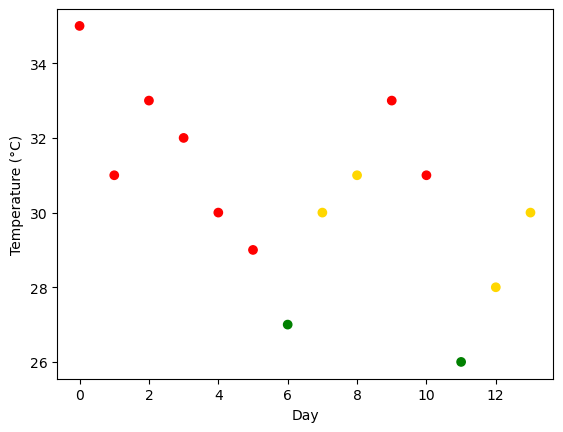

In [8]:
import matplotlib.pyplot as plt

temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

heat_level = []
colors = []

for it in range(len(temperatures)):
    temp = temperatures[it]

    if temp < 28:
        heat = 0

    if temp > 32:
        heat = 2

    if temp >= 28 and temp <= 32:
        heat = 1

        if heat_level[it - 1] == 2:
            heat = 2

    heat_level.append(heat)
    
    if heat == 0:
        colors.append('green')

    if heat == 1:
        colors.append('gold')

    if heat == 2:
        colors.append('red')


plt.scatter(range(len(temperatures)), temperatures, c=colors)
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.show()

Der Befehl plt.scatter erstellt eine Punktgrafik. Auf der x‑Achse tragen wir mit range(len(temperatures)) die Tage auf, also 0, 1, 2, … Auf der y‑Achse stehen die Maximaltemperaturen. Die Option c=colors sorgt dafür, dass jeder Punkt die Farbe erhält, die in der Liste colors für den jeweiligen Tag gespeichert ist. So kann man auf einen Blick erkennen, welche Tage grün, gelb und rot eingestuft wurden und wo längere Hitzephasen auftreten.

Das Programm funkioniert, aber die If-Abfrage ist noch nicht super ordentlich oder elegant. Meinst versucht man zu vermeiden, dass man mehrere If-Abfragen untereinander stehen hat, weil das recht fehleranfällig und ineffizent wäre. Wir sollten die If-Abfragen also verknüpfen: Wenn wir schon wissen, dass die Temperatur unter 28 ist, brauchen wir die anderen Abfragen ja gar nicht mehr. Wir können sie also in eine else packen. Auch den gelb-Test müssen wir nur machen, wenn wir ausgeschlossen haben, dass der Tag grün oder rot ist. Somit sparen wir uns auch automatisch die lange Abfrage mit dem and. Außerdem können wir das `heat = 1` in ein else geben, anstatt es vorher zu setzen und dann vom if überschreiben zu lassen.

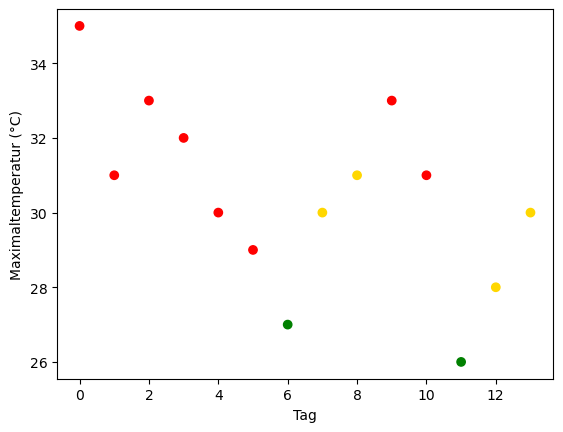

In [6]:
import matplotlib.pyplot as plt

temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

heat_level = []
colors = []

for it in range(len(temperatures)):
    temp = temperatures[it]

    if temp < 28:
        heat = 0
    else:
        if temp > 32:
            heat = 2
        else:      
            if heat_level[it - 1] == 2:
                heat = 2
            else:
                heat = 1

    heat_level.append(heat)
    if heat == 0:
        colors.append('green')

    if heat == 1:
        colors.append('gold')

    if heat == 2:
        colors.append('red')

plt.scatter(range(len(temperatures)), temperatures, c=colors)
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.show()

Nachteil: Jetzt sind wir durch die ganzen Einrückungen schon recht weit nach rechts geruscht, was den Code ein bisschen schwer lesbar macht. Da die Kombination von einem else, direkt gefolgt von einem if so häufig vorkommt, gibt es dafür einen eigenen Befehl: **elif**. Es ist genau das gleiche wie else: if: aber braucht eben nur eine Zeile und eine Einrückung.

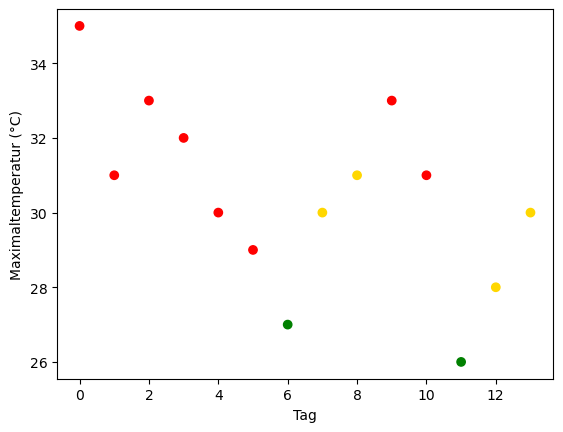

In [7]:
import matplotlib.pyplot as plt

temperatures = [35, 31, 33, 32, 30, 29, 27, 30, 31, 33, 31, 26, 28, 30]

heat_level = []
colors = []
for it in range(len(temperatures)):
    temp = temperatures[it]

    if temp < 28:
        heat = 0
    elif temp > 32:
        heat = 2
    elif heat_level[it - 1] == 2:
        heat = 2
    else:
        heat = 1

    heat_level.append(heat)


    if heat == 0:
        colors.append('green')

    if heat == 1:
        colors.append('gold')

    if heat == 2:
        colors.append('red')

plt.scatter(range(len(temperatures)), temperatures, c=colors)
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.show()

Auf diese Weise ist aus einer einfachen Liste von Temperaturen ein kleines Modell geworden, das Hitzetage klassifiziert und Hitzephasen sichtbar macht. Gleichzeitig wurden dabei grundlegende Programmierkonzepte verwendet: Schleifen über Listen, if‑Abfragen mit Vergleichsoperatoren und logischen Verknüpfungen, der Zugriff auf vorherige Listeneinträge über it - 1, und die grafische Darstellung von Zeitreihen mit matplotlib.

### Zusammenfassung

Eine **if‑Abfrage** prüft eine Bedingung und führt den eingerückten Code nur dann aus, wenn die Bedingung wahr ist. **else** gibt an, was passieren soll, wenn die Bedingung der zugehörigen if‑Abfrage nicht erfüllt ist. **elif** ist eine Kurzschreibweise von else: if: 

Mit den **Vergleichsoperatoren** <, >, <=, >= und == vergleicht man Werte: etwa „kleiner als“, „größer als“, „kleiner oder gleich“, „größer oder gleich“ und „gleich“. Der Operator != bedeutet „ungleich“. = hingegen ist kein Vergleich, sondern weist einer Variable einen neuen Wert zu (Zuweisung), während == prüft, ob zwei Werte gleich sind.

Das Schlüsselwort **and** verknüpft zwei Bedingungen logisch: Der gesamte Ausdruck ist nur dann wahr, wenn beide Teilbedingungen wahr sind. So kann man z.B. prüfen, ob ein Wert gleichzeitig größer als ein Untergrenzwert und kleiner als ein Obergrenzwert ist.

**Listenelemente** werden mit eckigen Klammern adressiert: liste[0] greift auf das erste Element zu, liste[1] auf das zweite usw. Der Index zählt ab 0, und mit dieser Schreibweise kann man gezielt einzelne Einträge lesen oder überschreiben.